# 🌱 CROP RECOMMENDATION USING MACHINE LEARNING

**Description:** Predicts the best crops based on soil nutrients and climate conditions using Random Forest Classifier

**Author:** PAIshanMadusha

**Date:** 2025/12/17

**Dataset:** Crop Recommendation Dataset (22 crops, 7 features)

**Link:** https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

# 1. PROJECT SETUP & DATA LOADING

In [2]:
# Install required packages for data analysis 
# Install visualization libraries
# Install scikit-learn for machine learning tasks
!pip install pandas numpy seaborn scikit-learn

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [13]:
# Load the dataset from a URL or local path
# url = "https://raw.githubusercontent.com/PAIshanMadusha/crop-recommendation-model/refs/heads/development/dataset/Crop_recommendation.csv"
# or
url = "..\\dataset\\Crop_recommendation.csv"
crop = pd.read_csv(url, encoding="latin-1")

In [14]:
# Display the first few rows of the dataset
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# 2. EXPLORATORY DATA ANALYSIS (EDA)

In [15]:
# Display the shape of the dataset(number of rows and columns)
crop.shape

(2200, 8)

In [16]:
# Display summary information about the dataset
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [17]:
# Check for missing values in the dataset
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [18]:
# Check for duplicate records in the dataset
crop.duplicated().sum()

np.int64(0)

In [19]:
# Display statistical summary of the dataset
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [20]:
# Display correlation matrix of numerical features
crop.corr(numeric_only=True)

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


# 3. DATA VISUALIZATION

In [21]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

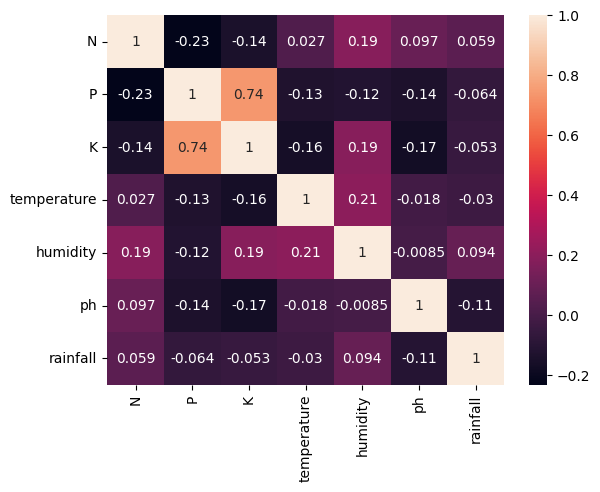

In [22]:
# Visualize the correlation matrix using a heatmap
sns.heatmap(crop.corr(numeric_only=True), annot=True, cbar=True)

In [23]:
# Display the distribution of the target variable 'label'
crop.label.value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [24]:
# Display unique crop labels in the dataset
crop["label"].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [25]:
# Display the number of unique crop labels in the dataset
crop["label"].unique().size

22

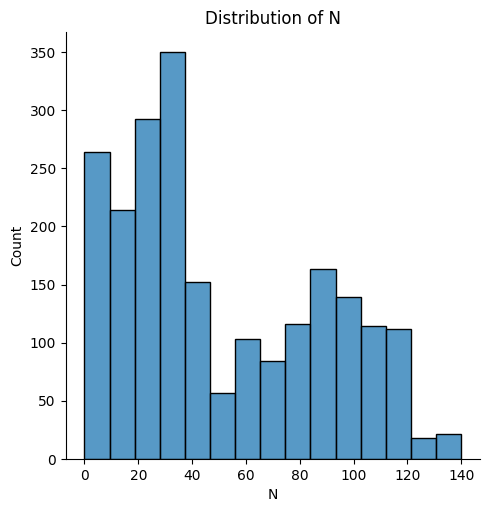

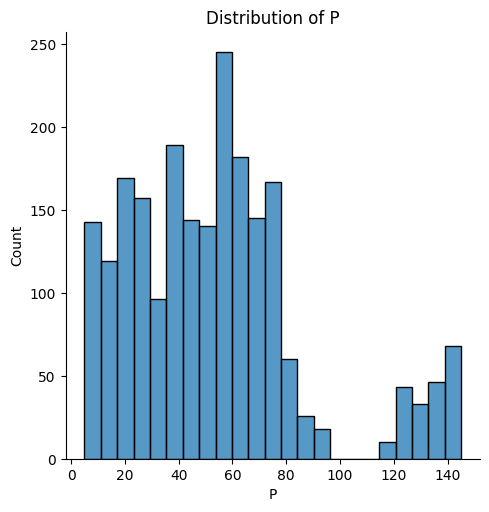

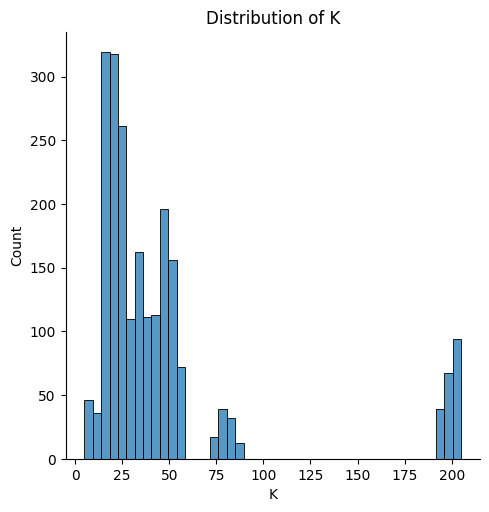

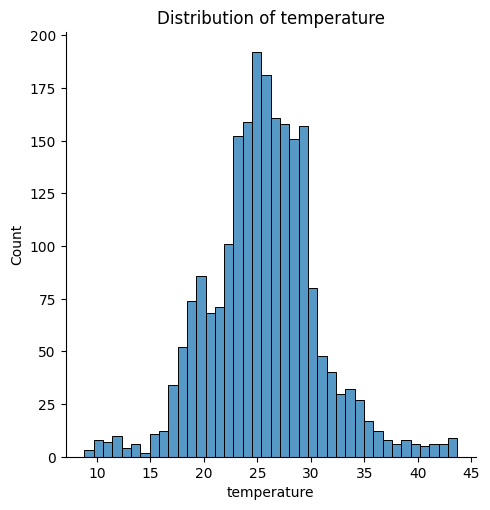

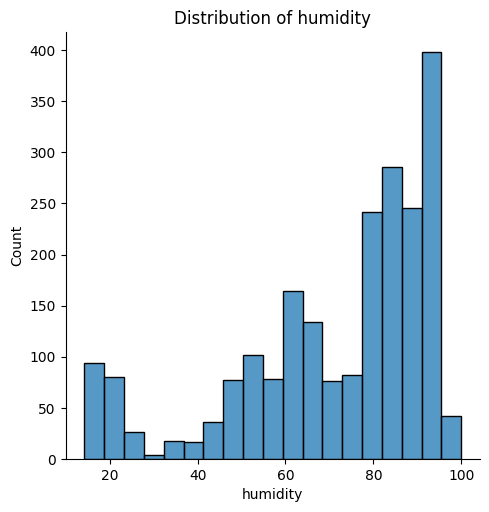

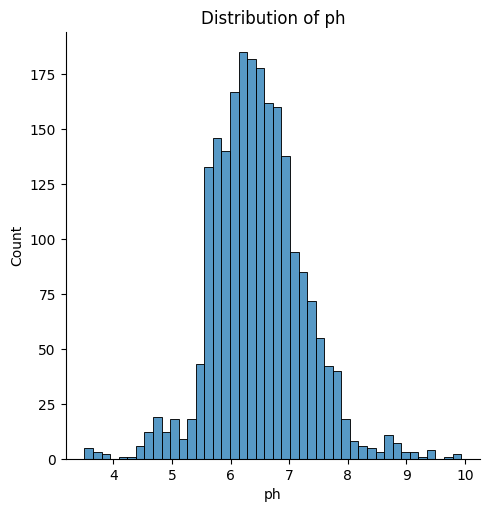

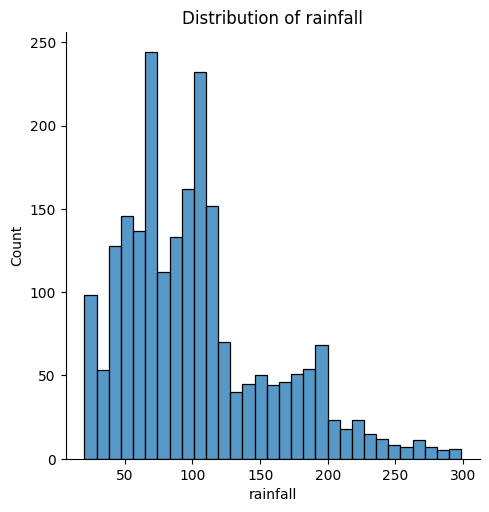

In [26]:
# Visualize the distribution of each feature using a loop for efficiency
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
for feature in features:
    sns.displot(crop[feature])
    plt.title(f"Distribution of {feature}")
    plt.show()

# 4. DATA PREPROCESSING

In [27]:
# Create a dictionary mapping crop names to numerical labels
crop_dict = {
    "rice": 1,
    "maize": 2,
    "chickpea": 3,
    "kidneybeans": 4,
    "pigeonpeas": 5,
    "mothbeans": 6,
    "mungbean": 7,
    "blackgram": 8,
    "lentil": 9,
    "pomegranate": 10,
    "banana": 11,
    "mango": 12,
    "grapes": 13,
    "watermelon": 14,
    "muskmelon": 15,
    "apple": 16,
    "orange": 17,
    "papaya": 18,
    "coconut": 19,
    "cotton": 20,
    "jute": 21,
    "coffee": 22
}
# Map crop names to numerical labels in the 'label' column
crop["label"] = crop["label"].map(crop_dict)

In [28]:
# Display the first few rows of the updated dataset
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [29]:
# Display the distribution of the target variable 'label'
crop.label.value_counts()

label
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
Name: count, dtype: int64

In [30]:
# Display unique crop labels in the dataset
crop["label"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22])

In [31]:
# Display the number of unique crop labels in the dataset
crop["label"].unique().size

22

In [32]:
# Verify no unmapped values
print(f"Missing values after mapping: {crop['label'].isnull().sum()}")

Missing values after mapping: 0


In [33]:
# Separate features (X) and target (y)
x = crop.drop("label", axis=1)
y = crop["label"]

In [34]:
# Display the first few rows of features
x.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [35]:
# Display the first few rows of target variable
y.head()

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64

# 5. MODEL TRAINING

In [50]:
# Import necessary modules from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

In [37]:
# Split the dataset into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [38]:
# Display the shape of the training feature set
print(f"Training set: {x_train.shape}")

Training set: (1760, 7)


In [39]:
# Display the shape of the testing feature set
print(f"Testing set: {x_test.shape}")

Testing set: (440, 7)


In [40]:
# Scale the features using StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [41]:
# Display the first few rows of the scaled training features
x_train

array([[-9.03426596e-01, -1.12616170e+00, -6.68506601e-01, ...,
         9.36586183e-01,  1.93473784e-01,  5.14970176e-03],
       [-3.67051340e-01,  7.70358846e-01, -5.70589522e-01, ...,
        -1.00470485e-01,  8.63917548e-01, -6.05290566e-01],
       [-1.17161422e+00,  5.89737842e-01, -4.53089028e-01, ...,
        -3.82774991e-01,  1.05029771e+00, -1.04580687e+00],
       ...,
       [-1.06433917e+00, -5.24091685e-01, -3.35588533e-01, ...,
        -8.98381379e-01, -6.34357580e-04, -4.37358211e-02],
       [-1.06433917e+00,  2.12501638e+00,  3.05234239e+00, ...,
         3.86340190e-01, -1.48467347e-01, -5.69036842e-01],
       [-5.01145154e-01,  7.40255346e-01, -5.11839275e-01, ...,
        -4.18045489e-01,  6.86860180e-01, -8.96531475e-01]],
      shape=(1760, 7))

In [42]:
# Display the first few rows of the scaled testing features
x_test

array([[ 1.34934948, -1.0960582 , -0.02225388, ...,  1.05232434,
        -0.37619899, -1.38984486],
       [ 1.26889319, -1.36698971,  0.05607978, ...,  0.67956909,
        -0.28013033, -0.96895253],
       [ 0.22296144,  0.25859933,  0.01691295, ...,  0.98974316,
         0.60209743,  0.22056087],
       ...,
       [ 1.88572474, -0.19295318, -0.62933977, ...,  0.35134079,
         1.61311363, -0.54905776],
       [ 1.75163092, -0.04243567, -0.57058952, ...,  0.1731198 ,
        -0.46741089, -0.64767698],
       [-1.22525175,  0.43922034, -0.55100611, ..., -1.74645651,
        -0.45817577,  0.95946086]], shape=(440, 7))

In [43]:
# Define a dictionary of machine learning models to evaluate
models = {
    # Logistic Regression for multi-class classification
    "LogisticRegression": LogisticRegression(max_iter=1000),
    # Gaussian Naive Bayes classifier for probabilistic classification
    "GaussianNB": GaussianNB(),
    # Support Vector Classifier for classification tasks
    "SVC": SVC(),
    # K-Nearest Neighbors Classifier for instance-based learning
    "KNeighborsClassifier": KNeighborsClassifier(),
    # Decision Tree Classifier for tree-based classification
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    # Extra Trees Classifier for ensemble learning
    "ExtraTreeClassifier": ExtraTreeClassifier(),
    # Random Forest Classifier for ensemble learning
    "RandomForestClassifier": RandomForestClassifier(),
    # Bagging Classifier for ensemble learning
    "BaggingClassifier": BaggingClassifier(),
    # Gradient Boosting Classifier for boosting ensemble learning
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    # AdaBoost Classifier for boosting ensemble learning
    "AdaBoostClassifier": AdaBoostClassifier(),
}

In [44]:
# Evaluate each model and print its accuracy
print("\nModel Accuracy Comparison:")
print("-" * 50)
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    score = accuracy_score(y_test, y_pred)
    print(f"{name}: {score}")


Model Accuracy Comparison:
--------------------------------------------------
LogisticRegression: 0.9636363636363636
GaussianNB: 0.9954545454545455
SVC: 0.9681818181818181
KNeighborsClassifier: 0.9659090909090909
DecisionTreeClassifier: 0.9840909090909091
ExtraTreeClassifier: 0.9090909090909091
RandomForestClassifier: 0.9931818181818182
BaggingClassifier: 0.990909090909091
GradientBoostingClassifier: 0.9818181818181818
AdaBoostClassifier: 0.14545454545454545


In [57]:
# Train the final model (RandomForestClassifier) and evaluate its accuracy
randfcl = RandomForestClassifier(random_state=42)
randfcl.fit(x_train, y_train)
y_pred = randfcl.predict(x_test)
final_accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Model Accuracy: {final_accuracy:.4f}")


Final Model Accuracy: 0.9932


# 6. MODEL EVALUATION

In [ ]:
# Generate and display the classification report for the final model
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=crop_dict.keys()))


Classification Report:
              precision    recall  f1-score   support

        rice       1.00      0.89      0.94        19
       maize       1.00      1.00      1.00        21
    chickpea       1.00      1.00      1.00        26
 kidneybeans       1.00      1.00      1.00        20
  pigeonpeas       1.00      1.00      1.00        23
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   blackgram       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
 pomegranate       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
      grapes       1.00      1.00      1.00        14
  watermelon       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
       apple       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        14
   

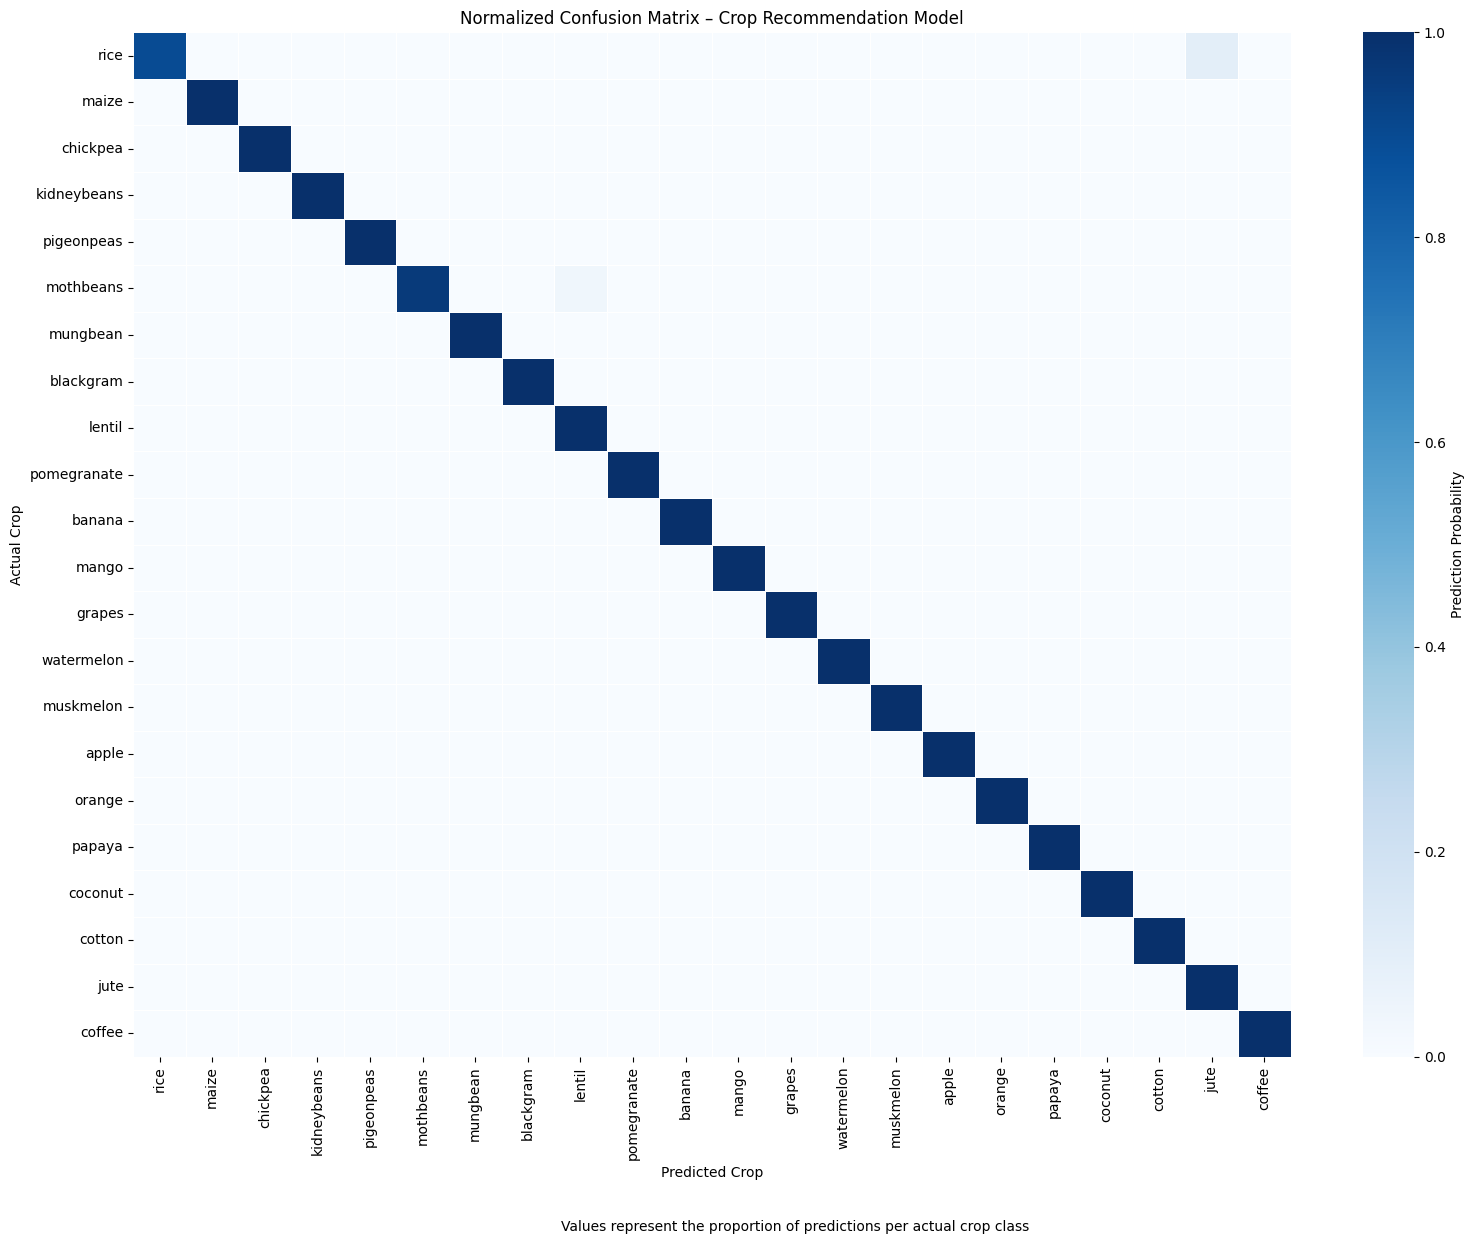

In [ ]:
# Generate and visualize the normalized confusion matrix for the final model
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=crop_dict.keys(),
    yticklabels=crop_dict.keys(),
    linewidths=0.5,
    cbar_kws={'label': 'Prediction Probability'}
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Normalized Confusion Matrix – Crop Recommendation Model")

plt.figtext(
    0.5, -0.03,
    "Values represent the proportion of predictions per actual crop class",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# 7. MODEL PREDICTION FUNCTION

In [60]:
# Create reverse dictionary for crop name lookup
crop_dict_reverse = {v: k for k, v in crop_dict.items()}

In [61]:
# Get feature names
crop.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [62]:
# Define the recommendation function
def recommendation(N, P, K, temperature, humidity, ph, rainfall, top_n=5):
    """
    Predict the best crops based on soil and climate conditions
    Returns top N crop recommendations with their probabilities
    """
    # Prepare input features
    features = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]], columns=sc.feature_names_in_)
    # Scale the input features
    scaled_features = sc.transform(features)
    
    # Get probability scores for all crops
    probabilities = randfcl.predict_proba(scaled_features)[0]
    
    # Get top N crop indices sorted by probability
    top_indices = np.argsort(probabilities)[::-1][:top_n]
    
    # Create results list
    recommendations = []
    for idx in top_indices:
        crop_num = randfcl.classes_[idx] # Get the crop number
        crop_name = crop_dict_reverse[crop_num] # Get the crop name
        probability = probabilities[idx] * 100  # Convert to percentage
        # Append the recommendation to the list
        recommendations.append({
            'crop': crop_name,
            'confidence': round(probability, 2) # Round to 2 decimal places
        })
    
    return recommendations

# 8. TESTING & VALIDATION

In [63]:
# Display the first few rows of the dataset
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [64]:
# Test with realistic values (rice-friendly conditions)
N = 90
P = 42
K = 43
temperature = 21
humidity = 82
ph = 6.5
rainfall = 200

# Get top 6 crop recommendations
top_crops = recommendation(N, P, K, temperature, humidity, ph, rainfall, top_n=6)

print(f"\n{'='*50}")
print(f"Top 6 Recommended Crops for Given Conditions:")
print(f"{'='*50}")
print(f"N: {N} | P: {P} | K: {K}")
print(f"Temperature: {temperature}°C | Humidity: {humidity}% | pH: {ph}")
print(f"Rainfall: {rainfall}mm")
print(f"{'='*50}")

# Print the recommendations
for i, crop_info in enumerate(top_crops, 1):
    print(f"{i}. {crop_info['crop'].capitalize():<15} - Confidence: {crop_info['confidence']:.2f}%")
print(f"{'='*50}")


Top 6 Recommended Crops for Given Conditions:
N: 90 | P: 42 | K: 43
Temperature: 21°C | Humidity: 82% | pH: 6.5
Rainfall: 200mm
1. Rice            - Confidence: 95.00%
2. Jute            - Confidence: 5.00%
3. Cotton          - Confidence: 0.00%
4. Coconut         - Confidence: 0.00%
5. Papaya          - Confidence: 0.00%
6. Coffee          - Confidence: 0.00%


# 9. MODEL SERIALIZATION (SAVING AS PICKLE)

In [65]:
# Save the trained model using pickle
import pickle

In [66]:
# Package everything together
model_package = {
    'model': randfcl,
    'scaler': sc,
    'crop_dict_reverse': crop_dict_reverse,
    'model_name': 'RandomForestClassifier',
    'accuracy': final_accuracy,
    'features': ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'],
    'num_crops': 22
}

# Save to one file 
with open("crop_model_complete.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("Model saved successfully!")
print(f"Model Type: {model_package['model_name']}")
print(f"Accuracy: {model_package['accuracy']:.4f}")
print(f"Number of Crops: {model_package['num_crops']}")
print("\nFile created: crop_model_complete.pkl")

Model saved successfully!
Model Type: RandomForestClassifier
Accuracy: 0.9932
Number of Crops: 22

File created: crop_model_complete.pkl


# 10. LOAD THE SAVED PICKLE

In [67]:
# Load the saved model to verify
# Change the path as necessary
with open('../model/crop_model_complete.pkl', 'rb') as file:
    model_package = pickle.load(file)

# Extract components
model = model_package['model']
scaler = model_package['scaler']
crop_dict_reverse = model_package['crop_dict_reverse']

print("Model loaded successfully!")
print(f"Model Type: {model_package['model_name']}")
print(f"Accuracy: {model_package['accuracy']:.4f}")
print(f"Features: {model_package['features']}")

Model loaded successfully!
Model Type: RandomForestClassifier
Accuracy: 0.9932
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


# 11. SAVED MODEL TESTING & VALIDATION

In [68]:
# Prediction function
def recommendation(N, P, K, temperature, humidity, ph, rainfall, top_n=6):
    """
    Predict the best crops based on soil and climate conditions
    """
    # Prepare input features
    features = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]], columns=sc.feature_names_in_)
    # Scale the input features
    scaled_features = scaler.transform(features)
    # Get probability scores for all crops
    probabilities = model.predict_proba(scaled_features)[0]
    # Get top N crop indices sorted by probability
    top_indices = np.argsort(probabilities)[::-1][:top_n]
    
    # Create results list
    recommendations = []
    for idx in top_indices:
        crop_num = model.classes_[idx] # Get the crop number
        crop_name = crop_dict_reverse[crop_num] # Get the crop name
        probability = probabilities[idx] * 100 # Convert to percentage
        # Append the recommendation to the list
        recommendations.append({
            'crop': crop_name,
            'confidence': round(probability, 2)
        })
    
    return recommendations

In [69]:
# Test the loaded model
N = 70
P = 40
K = 40
temperature = 20
humidity = 80
ph = 6.5
rainfall = 100

# Get top 6 crop recommendations
top_crops = recommendation(N, P, K, temperature, humidity, ph, rainfall, top_n=6)

print(f"\n{'='*60}")
print(f"Top 6 Recommended Crops:")
print(f"{'='*60}")
print(f"N: {N} | P: {P} | K: {K}")
print(f"Temperature: {temperature}°C | Humidity: {humidity}% | pH: {ph}")
print(f"Rainfall: {rainfall}mm")
print(f"{'='*60}")

# Print the recommendations
for i, crop_info in enumerate(top_crops, 1):
    print(f"{i}. {crop_info['crop'].capitalize():<15} - Confidence: {crop_info['confidence']:.2f}%")
print(f"{'='*60}")


Top 6 Recommended Crops:
N: 70 | P: 40 | K: 40
Temperature: 20°C | Humidity: 80% | pH: 6.5
Rainfall: 100mm
1. Rice            - Confidence: 26.00%
2. Jute            - Confidence: 24.00%
3. Maize           - Confidence: 12.00%
4. Banana          - Confidence: 10.00%
5. Papaya          - Confidence: 8.00%
6. Cotton          - Confidence: 6.00%


# ✅ END OF MODEL DEVELOPMENT